# Notebook 05: Sustancias Ilegales, Perfilamiento y Mercado (Microtráfico)

**Objetivos de este notebook:**
1. Calcular las prevalencias recientes (Últimos 12 meses) de las principales drogas ilícitas: Marihuana, Cocaína, Basuco y Éxtasis.
2. Hacer un perfilamiento socioeconómico (Nivel Educativo / Estrato) comparando consumidores de diferentes drogas.
3. Analizar la evolución del microtráfico: Canales de acceso ("Olla", Domicilio, Redes Sociales) según la sustancia.
4. Analizar los precios promedio pagados en el mercado ilegal.

**Nota analítica:** En el cruce de datos, si una persona no llegó al módulo de Cocaína (L), es porque no la consume. Por lo tanto, los `NaN` en las variables de consumo de estos módulos deben ser interpretados como "No", a excepción de quienes respondieron "No sabe/No responde" (9).

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['figure.figsize'] = (12, 7)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [12]:
BASE_DIR = Path('..')
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
FIGURES_DIR = BASE_DIR / 'outputs' / 'figures'

df = pd.read_parquet(PROCESSED_DIR / 'df_master.parquet')
df['fex_c'] = pd.to_numeric(df['fex_c'], errors='coerce').fillna(0)

def calcular_tasa_prevalencia(df, col_filtro, valor_positivo=1):
    """Calcula la tasa de prevalencia (en porcentaje) usando factor de expansión."""
    pob_total = df['fex_c'].sum()
    pob_positiva = df[df[col_filtro] == valor_positivo]['fex_c'].sum()
    return (pob_positiva / pob_total) * 100

print(f"Base cargada. Población representada: {df['fex_c'].sum():,.0f} personas.")

Base cargada. Población representada: 23,747,363 personas.


In [13]:
dicc_binario = {1: 1, 2: 0} # 1 = Sí, 2 = No

# PREVALENCIA 12 MESES (AÑO)
df['marihuana_12m'] = df['k_03'].map(dicc_binario).fillna(0) # Si es NaN, es 0 porque no entró al módulo
df['cocaina_12m'] = df['l_02'].map(dicc_binario).fillna(0)
df['basuco_12m'] = df['m_02'].map(dicc_binario).fillna(0)
df['extasis_12m'] = df['n_02'].map(dicc_binario).fillna(0)

print("Variables de prevalencia (12 meses) creadas y nulos imputados como no consumidores.")

Variables de prevalencia (12 meses) creadas y nulos imputados como no consumidores.


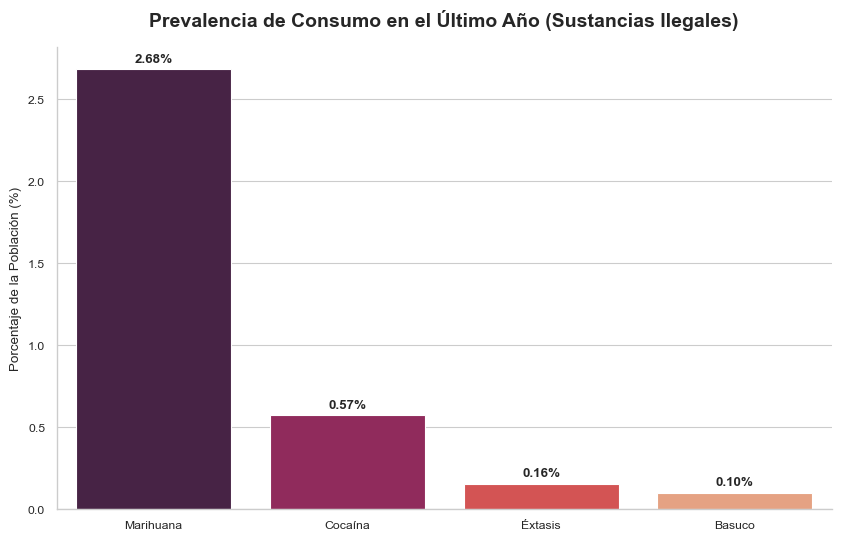

In [5]:
prevalencias_ilegales = {
    'Sustancia': ['Marihuana', 'Cocaína', 'Éxtasis', 'Basuco'],
    'Prevalencia_12M_Pct': [
        calcular_tasa_prevalencia(df, 'marihuana_12m'),
        calcular_tasa_prevalencia(df, 'cocaina_12m'),
        calcular_tasa_prevalencia(df, 'extasis_12m'),
        calcular_tasa_prevalencia(df, 'basuco_12m')
    ]
}
df_prev_il = pd.DataFrame(prevalencias_ilegales).sort_values(by='Prevalencia_12M_Pct', ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_prev_il, x='Sustancia', y='Prevalencia_12M_Pct', palette='rocket')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3, fontweight='bold')

plt.title('Prevalencia de Consumo en el Último Año (Sustancias Ilegales)', pad=15, fontweight='bold', fontsize=14)
plt.ylabel('Porcentaje de la Población (%)')
plt.xlabel('')
sns.despine()

plt.savefig(FIGURES_DIR / "08_prevalencias_ilegales.png", dpi=300, bbox_inches='tight')
plt.show()

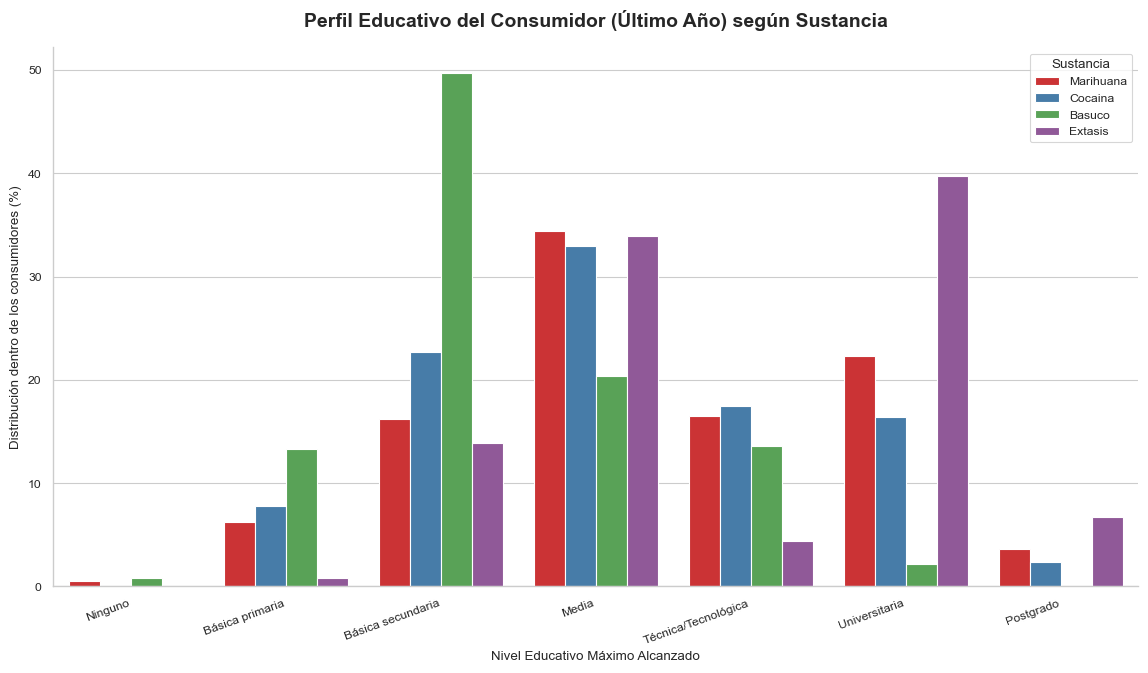

In [14]:
# Crear subsets ponderados por sustancia
def perfil_educativo(df, col_sustancia):
    df_sust = df[df[col_sustancia] == 1]
    resumen = df_sust.groupby('nivel_educativo')['fex_c'].sum().reset_index()
    resumen['Porcentaje'] = (resumen['fex_c'] / resumen['fex_c'].sum()) * 100
    resumen['Sustancia'] = col_sustancia.split('_')[0].capitalize()
    return resumen

# Consolidar data
perf_mar = perfil_educativo(df, 'marihuana_12m')
perf_coc = perfil_educativo(df, 'cocaina_12m')
perf_bas = perfil_educativo(df, 'basuco_12m')
perf_ext = perfil_educativo(df, 'extasis_12m')

df_perfiles = pd.concat([perf_mar, perf_coc, perf_bas, perf_ext])

# Orden de educación lógico
orden_edu = ['Ninguno', 'Básica primaria', 'Básica secundaria', 'Media', 'Técnica/Tecnológica', 'Universitaria', 'Postgrado']
df_perfiles = df_perfiles[df_perfiles['nivel_educativo'].isin(orden_edu)]

# Graficar
plt.figure(figsize=(14, 7))
sns.barplot(data=df_perfiles, x='nivel_educativo', y='Porcentaje', hue='Sustancia', order=orden_edu, palette='Set1')

plt.title('Perfil Educativo del Consumidor (Último Año) según Sustancia', pad=15, fontweight='bold', fontsize=14)
plt.ylabel('Distribución dentro de los consumidores (%)')
plt.xlabel('Nivel Educativo Máximo Alcanzado')
plt.xticks(rotation=20, ha='right')
sns.despine()

plt.savefig(FIGURES_DIR / "09_perfil_educativo_sustancias.png", dpi=300, bbox_inches='tight')
plt.show()

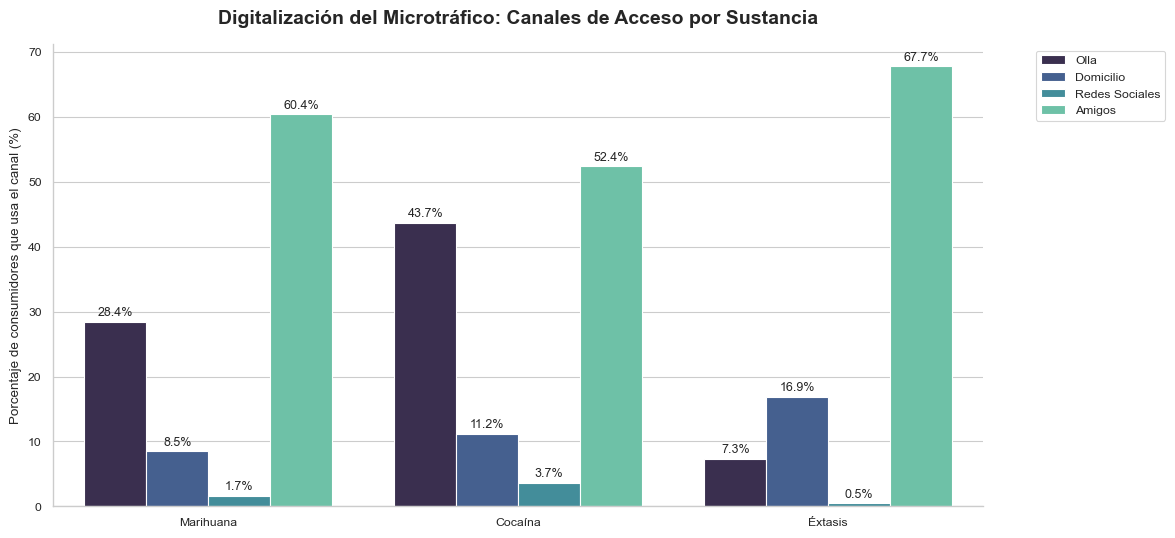

In [18]:
# Definir los canales de acceso para cada sustancia basado en el diccionario
canales = {
    'Marihuana': {'Olla': 'k_10_c', 'Domicilio': 'k_10_e', 'Redes Sociales': 'k_10_b', 'Amigos': 'k_10_d'},
    'Cocaína': {'Olla': 'l_09_c', 'Domicilio': 'l_09_e', 'Redes Sociales': 'l_09_b', 'Amigos': 'l_09_d'},
    'Éxtasis': {'Olla': 'n_10_c', 'Domicilio': 'n_10_e', 'Redes Sociales': 'n_10_b', 'Amigos': 'n_10_d'}
}

data_canales = []

for droga, columnas in canales.items():
    # Nombre de la columna de consumo de 12 meses para esta droga
    col_consumo = f"{droga.lower().replace('ó','o').replace('í','i').replace('é','e')}_12m"
    # Población total que consume esta droga
    pob_total_droga = df[df[col_consumo] == 1]['fex_c'].sum()
    
    for canal, col_dane in columnas.items():
        if col_dane in df.columns:
            # Población que respondió '1' (Sí) a ese canal específico
            pob_canal = df[df[col_dane] == 1]['fex_c'].sum()
            # Calcular porcentaje dentro de los consumidores de la droga
            porcentaje = (pob_canal / pob_total_droga) * 100 if pob_total_droga > 0 else 0
            
            data_canales.append({'Sustancia': droga, 'Canal de Acceso': canal, 'Uso del Canal (%)': porcentaje})

df_canales = pd.DataFrame(data_canales)

# Graficar
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_canales, x='Sustancia', y='Uso del Canal (%)', hue='Canal de Acceso', palette='mako')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2, fontsize=9)

plt.title('Digitalización del Microtráfico: Canales de Acceso por Sustancia', pad=15, fontweight='bold', fontsize=14)
plt.ylabel('Porcentaje de consumidores que usa el canal (%)')
plt.xlabel('')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()

plt.savefig(FIGURES_DIR / "10_canales_microtrafico.png", dpi=300, bbox_inches='tight')
plt.show()

In [19]:
# Convertir a numérico
df['precio_marihuana'] = pd.to_numeric(df['k_09_valor'], errors='coerce')
df['precio_cocaina'] = pd.to_numeric(df['l_08_valor'], errors='coerce')
df['precio_extasis'] = pd.to_numeric(df['n_09'], errors='coerce') # Para éxtasis la var suele ser n_09 o n_09_valor

# Limpieza estricta de outliers o códigos de error (ej. respuestas 98, 9999, o > $1,000,000)
def limpiar_precios(x, max_val):
    if pd.isna(x) or x <= 0 or x >= max_val:
        return np.nan
    return x

# Asumimos máximos lógicos por un gramo/pepa/cigarrillo para evitar errores de digitación del encuestador
df['precio_marihuana'] = df['precio_marihuana'].apply(lambda x: limpiar_precios(x, 50000)) # cigarrillo
df['precio_cocaina'] = df['precio_cocaina'].apply(lambda x: limpiar_precios(x, 200000))   # gramo
df['precio_extasis'] = df['precio_extasis'].apply(lambda x: limpiar_precios(x, 300000))   # pepa/cristal

# Calcular promedio ponderado por sustancia
precios = {}
for sust, col_precio in zip(['Marihuana (Cigarrillo)', 'Cocaína (Gramo)', 'Éxtasis (Pastilla)'], 
                            ['precio_marihuana', 'precio_cocaina', 'precio_extasis']):
    
    # Filtrar válidos
    validos = df[df[col_precio].notna()]
    if len(validos) > 0:
        promedio = np.average(validos[col_precio], weights=validos['fex_c'])
        precios[sust] = promedio

df_precios = pd.DataFrame(list(precios.items()), columns=['Sustancia/Unidad', 'Precio Promedio Ponderado ($ COP)'])

# Formatear como moneda colombiana
df_precios['Precio Formateado'] = df_precios['Precio Promedio Ponderado ($ COP)'].apply(lambda x: f"${x:,.0f} COP")

display(df_precios)

,Sustancia/Unidad,Precio Promedio Ponderado ($ COP),Precio Formateado
0,Marihuana (Cigarrillo),3058.783764,"$3,059 COP"
1,Cocaína (Gramo),10910.270491,"$10,910 COP"
2,Éxtasis (Pastilla),18999.142817,"$18,999 COP"
